# 11 · 투영·공분산·SVD를 PCA로 연결하기

**이번 질문:** 784차원 이미지나 2차원 점들을 더 적은 숫자로 압축하고 되돌리려면 어느 방향을 남겨야 할까요? 그 "방향"은 어떻게 계산하고, 버린 만큼의 오차는 얼마일까요?

00번의 내적을 **투영**으로 읽고, 관측들의 퍼짐을 **공분산 행렬**로 모은 뒤, 그 행렬의 **고유벡터**가 가장 많이 퍼진 방향이라는 것을 SVD로 계산합니다. 이 방향 $k$개를 남기는 것이 PCA입니다.
2차원 점들로 손계산을 하고, 같은 계산을 MNIST 7에 적용해 주성분 몇 개로 복원되는지 봅니다.

- 준비물: [00](../00_기초/00_math_to_numpy.ipynb)의 내적·행렬곱, [01](../00_기초/01_gradients_and_learning.ipynb)의 미분으로 최소 찾기.
- 도착점: 투영·공분산·PCA를 직접 쓰고 복원 오차를 두 가지 방법(직접 계산, 버린 고유값의 합)으로 검산합니다.
- 다음 연결: [12 Gaussian·정보](12_gaussian_information.ipynb)는 공분산으로 샘플을 만들고 로그 밀도를 계산합니다. 이후 Autoencoder는 $Z=X_cQ$를 비선형 encoder로 확장합니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 단위 방향 $q$ 위의 좌표는 내적 $z=x^\top q$이고 그 방향 위의 가장 가까운 점은 $\hat x=zq$입니다. 직교 방향 $k$개를 열로 모은 $Q$이면 `Z = X @ Q`, `X_hat = Z @ Q.T`.
2. 공분산 $C=X_c^\top X_c/N$의 고유벡터가 관측이 가장 많이 퍼진 방향이고 고유값이 그 방향의 분산입니다. SVD $X_c=U\,\mathrm{diag}(s)\,V^\top$에서 $V$의 열이 그 고유벡터, $s^2/N$이 고유값입니다.
3. PCA는 큰 고유값 $k$개의 방향을 남깁니다. 복원 오차(관측별 제곱 거리의 평균)는 **버린 고유값의 합**과 같고, 남긴 분산 비율은 $\sum_{j\le k}\lambda_j/\sum_j\lambda_j$입니다.

| 기호 | shape | 의미 |
|---|---|---|
| $X$ | $(N,D)$ | 행마다 하나의 관측 |
| $\mu$ | $(D,)$ | 학습 관측의 열별 평균 |
| $X_c=X-\mu$ | $(N,D)$ | 중심을 옮긴 관측 |
| $Q$ | $(D,k)$ | 남길 서로 직교하는 단위 방향 |
| $Z=X_cQ$ | $(N,k)$ | 압축 좌표 |
| $\hat X=ZQ^T+\mu$ | $(N,D)$ | 원래 좌표계의 복원 |

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/linalg_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(4절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/linalg_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.linalg_plots import (
    plot_curves, plot_projection_2d, plot_projection_images, plot_least_squares, plot_covariance_small,
    plot_covariance_images, plot_eigen_images, plot_eigen_directions, plot_pca_reconstruction, plot_pca_clouds,
)

# 3) 그림 설정. 배열 출력은 소수 5자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=5, suppress=True)

### 📎 이 노트북의 예시: 2차원 점, MNIST 5,000장

- **2차원 점.** 손계산 점 $(2,0)$, 관측 3개짜리 작은 표, 그리고 기울어진 타원 모양으로 퍼진 점 240개(학습)·160개(검증). 그림에서 방향과 오차를 직접 볼 수 있습니다.
- **MNIST 5,000장.** 00번부터 쓴 학습 집합 앞 5,000장을 $(5000, 784)$ 행렬로 봅니다. 평균 이미지, 화소별 분산, 고유 이미지, 7의 복원을 같은 수식으로 계산합니다. 고정 예시 7이 압축·복원의 대상입니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `mnist_examples[7].reshape(-1)`: (28, 28) 이미지를 (784,) 벡터로 폅니다. `-1`은 "나머지를 알아서"입니다.
> - `_`: 함수가 돌려준 값 중 쓰지 않는 것을 받아 버리는 관례상의 이름입니다.

In [2]:
mnist_examples, mnist_labels = load_examples(download=True)          # (10, 28, 28) 예시 이미지 10장, (10,) 정답 숫자
mnist_7 = mnist_examples[7].reshape(-1)                               # (784,): 고정 예시 7을 벡터로
mnist_X_all, mnist_y_all, _, _ = load_mnist()                         # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
mnist_X = mnist_X_all[:5000]                                          # (5000, 784): 학습 집합 앞 5,000장
print("이미지 행렬", mnist_X.shape, "· 7", mnist_7.shape)

이미지 행렬 (5000, 784) · 7 (784,)


## 🔑 1. 내적에서 길이와 투영으로

**이 절에서 가져갈 것:** 길이 1인 방향 $q$에서 본 $x$의 좌표는 내적 $z=x^\top q$이고, 그 방향 위에서 $x$에 가장 가까운 점은 $\hat x=zq$입니다. 잔차 $x-\hat x$는 $q$에 수직이고, 이것이 차원을 줄일 때 남는 오차입니다.

점 $x=(2,0)$을 대각선 방향 $q=(1,1)/\sqrt2$ 위의 한 점으로 대신하고 싶습니다. 대각선 위의 점은 $zq$ 꼴이므로 숫자 $z$ 하나만 고르면 됩니다. 어떤 $z$가 $x$에 가장 가까울까요?

> **용어**
>
> - **길이(norm)** $\|x\|_2=\sqrt{x^\top x}$: 자기 자신과의 내적의 제곱근. **단위 벡터**는 길이 1인 벡터.
> - **투영(projection)**: 점 $x$를 방향 $q$ 위의 가장 가까운 점 $\hat x=(x^\top q)q$로 옮기는 것. 코드에서는 `z = x @ q`, `x_hat = z * q`.
> - **직교(orthogonal)**: 내적이 0. 잔차 $r=x-\hat x$는 $q$와 직교합니다.

벡터 $x$의 길이는 $\|x\|_2=\sqrt{x^Tx}$입니다. 길이가 1인 방향 $q$에서 본 좌표는 $z=x^Tq$, 그 방향 위의 점은 $\hat x=zq$입니다.
잔차 $r=x-\hat x$가 $q$에 직교한다는 말은 $q^Tr=0$이라는 뜻입니다.

왜 이 점이 가장 가까울까요? $f(z)=\tfrac12\|x-zq\|^2$를 미분하면
$f'(z)=-q^Tx+zq^Tq$입니다. 단위 방향에서 $q^Tq=1$이므로 $z=q^Tx$가 됩니다.

손계산: $x=(2,0)$, $q=(1,1)/\sqrt2$이면 $z=\sqrt2$, $\hat x=(1,1)$, $r=(1,-1)$입니다.
여러 방향을 열로 모은 $Q$가 $Q^TQ=I_k$를 만족하면 같은 계산이 $Z=XQ$, $\hat X=XQQ^T$가 됩니다.
여기서 $I_k$는 대각선이 1인 $k\times k$ 단위행렬입니다.

> **코드**
>
> - `np.array([1., 1.]) / np.sqrt(2)`: 벡터를 길이로 나누어 단위 벡터로. `np.linalg.norm(v)`가 길이 $\|v\|_2$입니다.
> - `mnist_7[None]`, `img_q[:, None]`: (784,)를 행 하나짜리 `(1, 784)`와 열 하나짜리 `(784, 1)`로. `project`는 행 = 관측, 열 = 방향인 행렬을 받습니다.
> - `P @ P`: 투영 행렬을 두 번 곱한 것. 같으면 "한 번 투영한 점을 다시 투영해도 그대로"입니다.

In [3]:
proj_x = np.array([2., 0.])                                           # (2,): 점 x
proj_q = np.array([1., 1.]) / np.sqrt(2)                              # (2,): 길이 1인 대각선 방향 q
proj_z = proj_x @ proj_q                                              # 좌표 z = xᵀq = √2
proj_hat = proj_z * proj_q                                            # (2,): 방향 위의 점 x̂ = zq = (1, 1)
proj_r = proj_x - proj_hat                                            # (2,): 잔차 r = (1, −1)
np.testing.assert_allclose(proj_r @ proj_q, 0, atol=1e-14)            # 검산: 잔차 ⊥ 방향
print("z =", proj_z.round(4), "· x̂ =", proj_hat, "· r =", proj_r)

z = 1.4142 · x̂ = [1. 1.] · r = [ 1. -1.]


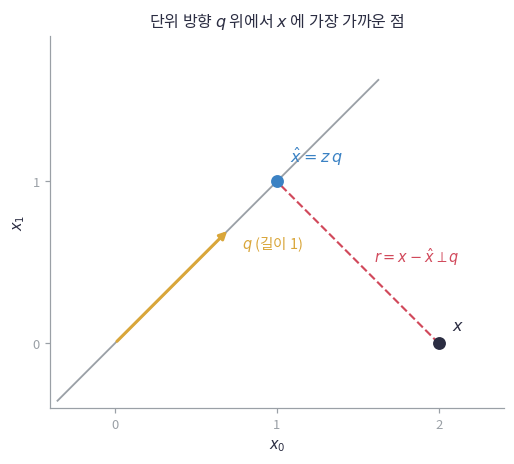

In [4]:
plot_projection_2d(proj_x, proj_q, proj_hat)

🔍 **확인** · 회색 직선이 방향 $q$가 만드는 선이고, 파란 점이 $x$에서 그 선으로 수직으로 내린 발 $\hat x=(1,1)$입니다. 빨간 점선이 잔차이며 방향에 수직입니다. 차원을 줄이면 이 수직 성분이 복원 오차로 남습니다.

### 🔍 같은 투영을 이미지에서 보면

784차원에서도 계산은 같습니다. 00번의 7 템플릿을 길이 1로 만든 $q$에 7 이미지를 투영하면 좌표 하나 $z$와, 템플릿 모양의 $\hat x$, 그리고 남는 잔차가 나옵니다.

In [5]:
# 쓰는 것: mnist_X_all, mnist_y_all, mnist_7 (📎 데이터 셀)
template_7 = mnist_X_all[mnist_y_all == 7].mean(axis=0) - mnist_X_all.mean(axis=0)   # (784,): 00번의 7 템플릿
img_q = template_7 / np.linalg.norm(template_7)                       # (784,): 길이 1인 방향
img_z = mnist_7 @ img_q                                               # 좌표 하나
img_hat = img_z * img_q                                               # (784,): 방향 위의 점
img_r = mnist_7 - img_hat                                             # (784,): 잔차
np.testing.assert_allclose(img_r @ img_q, 0, atol=1e-12)              # 검산: 잔차 ⊥ 방향
print("z =", img_z.round(3), "· ‖x‖² =", (mnist_7 @ mnist_7).round(2), "= z² + ‖r‖² =", (img_z ** 2 + img_r @ img_r).round(2))

z = 1.862 · ‖x‖² = 39.2 = z² + ‖r‖² = 39.2


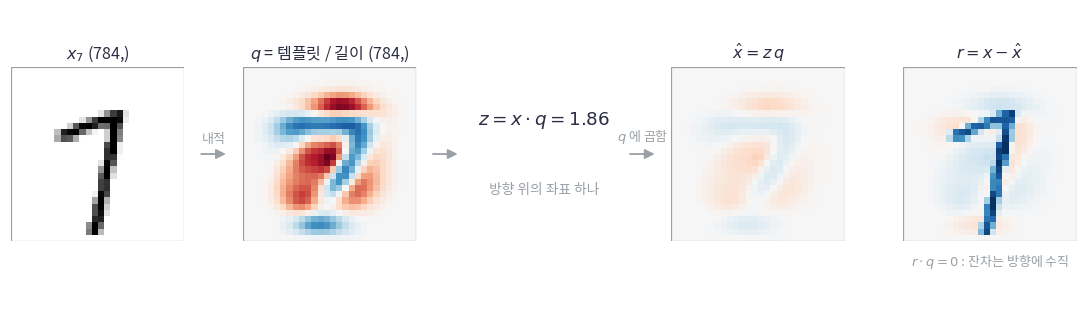

In [6]:
plot_projection_images(mnist_7.reshape(28, 28), img_q.reshape(28, 28), img_z, img_hat.reshape(28, 28), img_r.reshape(28, 28))

🔍 **확인** · 7 이미지 전체가 숫자 $z$ 하나로 줄었고, 되돌린 $\hat x$는 템플릿을 $z$배 한 이미지입니다. 잔차에는 이 7만의 획(템플릿과 다른 부분)이 남습니다. $\|x\|^2=z^2+\|r\|^2$가 정확히 성립하는 것이 직교의 뜻입니다.
아래 구현은 방향 여러 개를 열로 모은 $Q$에 대한 좌표와 복원입니다.

In [7]:
def project(X, Q):
    """직교 단위 방향들로의 좌표와 복원: Z = XQ, X̂ = ZQᵀ. X: (N, D), Q: (D, k)이고 QᵀQ = I → (Z: (N, k), X̂: (N, D))."""
    coordinates = X @ Q                                     # (N, k): 방향마다 내적
    reconstruction = coordinates @ Q.T                      # (N, D): 좌표를 원래 좌표계로
    return coordinates, reconstruction

In [8]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · img_q, img_z, img_hat (1절 7 그림 셀)
x = np.array([[2., 0.]])                                    # (1, 2): 손계산 점을 행 하나짜리 행렬로
q = np.array([[1.], [1.]]) / np.sqrt(2)                     # (2, 1): 방향을 열 하나짜리 행렬로
z, x_hat = project(x, q)
np.testing.assert_allclose(z, [[np.sqrt(2)]])               # 검산: 좌표 √2
np.testing.assert_allclose(x_hat, [[1., 1.]])               # 검산: 복원 (1, 1)
np.testing.assert_allclose((x - x_hat) @ q, 0, atol=1e-14)  # 검산: 잔차 ⊥ 방향
P = q @ q.T                                                 # (2, 2): 투영 행렬
np.testing.assert_allclose(P @ P, P)  # 검산: 같은 부분공간으로 두 번 투영해도 같습니다.
print('좌표:', z, '복원:', x_hat, '잔차:', x - x_hat)
img_z_fn, img_hat_fn = project(mnist_7[None], img_q[:, None])
np.testing.assert_allclose(img_z_fn, [[img_z]])             # 검산: 위 7 그림의 좌표와 같음
np.testing.assert_allclose(img_hat_fn[0], img_hat)          # 검산: 복원도 같음

좌표: [[1.41421]] 복원: [[1. 1.]] 잔차: [[ 1. -1.]]


🔍 **확인** · 손계산 $(2,0)$과 7 이미지 모두 `project`가 같은 값을 냅니다. 투영 행렬 $P=qq^\top$은 두 번 곱해도 같습니다. 이미 직선 위에 있는 점은 그대로이기 때문입니다.

### 🔑 일반적인 열들의 조합: 최소제곱

**이 절에서 가져갈 것:** 열이 직교 단위가 아닌 일반 행렬 $A$의 열을 섞어 $y$를 맞추려면, 내적 대신 정규방정식 $A^\top Aw=A^\top y$를 풉니다. 잔차가 $A$의 모든 열에 직교한다는 같은 조건입니다.

> **용어** · **최소제곱(least squares)·정규방정식(normal equation)**: $\|Aw-y\|^2$를 최소로 하는 $w$를 찾는 문제와, 기울기를 0으로 둔 식 $A^\top(Aw-y)=0$. 코드에서는 `np.linalg.solve(A.T @ A, A.T @ y)`.

열들이 단위·직교 방향일 때는 내적만으로 좌표를 얻었습니다. 일반적인 행렬 $A\in\mathbb R^{N\times k}$의 열을 섞어 $y\in\mathbb R^{N\times1}$를 맞추면
$\min_w\tfrac12\|Aw-y\|^2$의 기울기는 $A^T(Aw-y)$입니다.
열들이 선형 독립이면 $A^TAw=A^Ty$를 풀어 계수를 얻습니다. `solve(M, b)`는 $Mw=b$의 해를 계산합니다.
`lstsq`는 최소제곱을 직접 푸는 분해 기반 함수입니다. 두 계산을 작은 예제로 대조합니다.

아래는 점 4개에 직선 $y=w_0+w_1x$를 맞추는 예입니다. $A$의 첫 열은 1(절편), 둘째 열은 $x$입니다.

> **코드**
>
> - `np.column_stack([np.ones(4), ls_x])`: 1로 된 열(절편)과 x 열을 나란히 붙인 `(4, 2)` 행렬 A.
> - `np.linalg.solve(M, b)`: 연립방정식 Mw = b의 해. 여기서는 정규방정식 AᵀA w = Aᵀy를 풉니다.
> - `np.linalg.lstsq(A, y, rcond=None)[0]`: 최소제곱을 분해로 직접 푼 해. 돌려주는 네 값 중 첫 번째만 씁니다.

In [9]:
ls_x = np.array([-1., 0., 1., 2.])                                    # (4,): 점 4개의 x
ls_y = np.array([0., 1., 1., 3.])                                     # (4,): y
ls_A = np.column_stack([np.ones(4), ls_x])                            # (4, 2): [1, x]
ls_w = np.linalg.solve(ls_A.T @ ls_A, ls_A.T @ ls_y)                  # (2,): 정규방정식의 해 (w0, w1)
ls_r = ls_A @ ls_w - ls_y                                             # (4,): 잔차
np.testing.assert_allclose(ls_A.T @ ls_r, 0, atol=1e-12)              # 검산: 잔차가 두 열에 모두 직교
print("직선 y =", ls_w[0].round(3), "+", ls_w[1].round(3), "x · 잔차", ls_r.round(3))

직선 y = 0.8 + 0.9 x · 잔차 [-0.1 -0.2  0.7 -0.4]


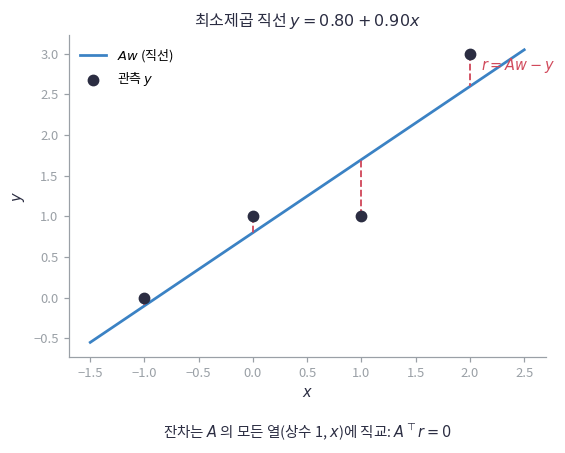

In [10]:
plot_least_squares(ls_x, ls_y, ls_w, ls_r)

🔍 **확인** · 파란 직선이 정규방정식으로 찾은 최소제곱 직선이고, 빨간 선분이 잔차입니다. 잔차 벡터는 절편 열(모두 1)과 $x$ 열에 모두 직교하므로 잔차의 합이 0이고 $\sum x_nr_n=0$입니다.
1절의 투영은 $A$의 열이 직교 단위일 때의 특수한 경우입니다. 그때는 $A^\top A=I$라 풀 것이 없습니다.

In [11]:
def normal_equation(A, y):
    """정규방정식 AᵀA w = Aᵀy의 해. A: (N, k) 열이 선형 독립, y: (N, 1) → w: (k, 1)."""
    return np.linalg.solve(A.T @ A, A.T @ y)

In [12]:
# 쓰는 것: ls_w (최소제곱 그림 셀)
A = np.column_stack([np.ones(4), np.array([-1., 0., 1., 2.])])       # (4, 2): 위와 같은 [1, x]
y = np.array([[0.], [1.], [1.], [3.]])                                # (4, 1): y를 열벡터로
w = normal_equation(A, y)                                             # (2, 1)
w_reference = np.linalg.lstsq(A, y, rcond=None)[0]                    # (2, 1): 분해 기반 해
np.testing.assert_allclose(w, w_reference)                            # 검산: solve = lstsq
np.testing.assert_allclose(A.T @ (A @ w - y), 0, atol=1e-14)          # 검산: 잔차 ⊥ 모든 열
print('최소제곱 계수:', w.ravel())
np.testing.assert_allclose(w.ravel(), ls_w)                           # 검산: 위 그림의 직선과 같음

최소제곱 계수: [0.8 0.9]


🔍 **확인** · `solve`로 푼 정규방정식의 해와 `lstsq`의 해가 같고, 위 그림의 직선과도 같습니다.

## 🔑 2. 분산을 행렬로 모으기

**이 절에서 가져갈 것:** 평균을 뺀 관측 $X_c$에서 $C=X_c^\top X_c/N$은 좌표 쌍마다 "같이 커지는 정도"를 모은 $(D,D)$ 대칭 행렬입니다. 대각선은 분산이고, 어떤 방향 $v$의 분산도 $v^\top Cv$로 한 번에 나옵니다.

관측 3개의 표 `[[1,2],[3,0],[5,4]]`를 봅시다. 첫 좌표가 평균보다 클 때 둘째 좌표도 큰 경향이 있으면 두 좌표는 같이 움직입니다. 그 정도를 곱해서 평균낸 것이 공분산입니다.

> **용어**
>
> - **중심화(centering)** $X_c=X-\mu$: 열별 평균을 빼서 평균이 0이 되게 옮기는 것. 00b의 중심화와 같습니다.
> - **공분산 행렬(covariance matrix)** $C$: $C_{ij}$는 좌표 $i$와 $j$가 같이 커지는 정도, $C_{jj}$는 좌표 $j$의 분산. 코드에서는 `Xc.T @ Xc / N`.
> - **양의 준정부호(positive semidefinite)**: 모든 $v$에 대해 $v^\top Cv\ge0$인 대칭 행렬. 어떤 방향의 분산도 음수가 아니라는 뜻입니다.

학습 관측 $N$개를 같은 확률 $1/N$로 고르는 경험 분포를 생각합니다.
$\mu_j=\tfrac1N\sum_nX_{nj}$이고, 공분산의 $(i,j)$ 성분은
$C_{ij}=\tfrac1N\sum_n(X_{ni}-\mu_i)(X_{nj}-\mu_j)$입니다.
같이 커지는 두 좌표에는 양의 공분산이 생깁니다. 대각선 $C_{jj}$는 각 좌표의 분산입니다.

배열로는 $C=X_c^TX_c/N$입니다. `Xc.T @ Xc`는 관측 축 $n$을 합합니다.
여기서는 경험 분포와 Gaussian 최대우도에 맞춰 **분모 $N$**을 사용합니다.
모집단 공분산의 불편 추정량을 다룰 때 쓰는 $N-1$ 규약은 같은 합에 $N/(N-1)$을 곱한 값입니다.

모든 $v$에 대해 $v^TCv=\|X_cv\|^2/N\ge0$입니다. 이런 대칭 행렬을 양의 준정부호라고 합니다.

> **코드**
>
> - `np.diag(C)`: 정사각 행렬의 대각선 원소 `(D,)`. 공분산의 대각선이 분산입니다.
> - `np.cov(X, rowvar=False, ddof=0)`: NumPy의 공분산. 행이 관측이므로 `rowvar=False`, 분모 N이므로 `ddof=0`.
> - `np.repeat(small, 2, axis=0)`: 행마다 두 번씩 되풀이해 관측을 두 배로. 경험 분포는 같습니다.

In [13]:
cov_X = np.array([[1., 2.], [3., 0.], [5., 4.]])                      # (N=3, D=2): 관측 3개
cov_mu = cov_X.mean(axis=0)                                           # (2,): 열별 평균 = (3, 2)
cov_Xc = cov_X - cov_mu                                               # (3, 2): 중심화
cov_C = cov_Xc.T @ cov_Xc / len(cov_X)                                # (2, 2): 관측 축을 합하고 N으로 나눔
np.testing.assert_allclose(cov_C, [[8 / 3, 4 / 3], [4 / 3, 8 / 3]])   # 검산: 손계산. 대각선 (4 + 0 + 4)/3, 비대각선 (4 + 0 + 4)/3
print("μ =", cov_mu, "\nXc\n", cov_Xc, "\nC\n", cov_C)

μ = [3. 2.] 
Xc
 [[-2.  0.]
 [ 0. -2.]
 [ 2.  2.]] 
C
 [[2.66667 1.33333]
 [1.33333 2.66667]]


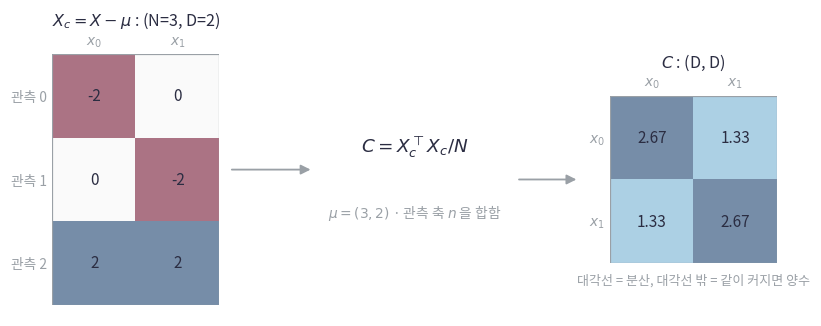

In [14]:
plot_covariance_small(cov_Xc, cov_C, cov_mu)

🔍 **확인** · 중심화한 표에서 두 열을 같은 관측끼리 곱해 더하고 3으로 나누면 $C$입니다. 대각선 $8/3$은 각 좌표의 분산, 대각선 밖 $4/3$은 두 좌표가 같이 커지는 정도입니다. 관측 0과 2에서 두 좌표가 같은 부호로 벗어나 양수가 됐습니다.

### 🔍 같은 계산을 이미지에서 보면

5,000장의 이미지 행렬 $(5000, 784)$에 같은 식을 쓰면 $\mu$는 평균 이미지, $C$는 $784\times784$ 행렬입니다. $C$의 대각선은 화소별 분산이고, 이미지로 그릴 수 있습니다.

In [15]:
# 쓰는 것: mnist_X (📎 데이터 셀)
mnist_mu = mnist_X.mean(axis=0)                                       # (784,): 평균 이미지
mnist_Xc = mnist_X - mnist_mu                                         # (5000, 784): 중심화
mnist_C = mnist_Xc.T @ mnist_Xc / len(mnist_X)                        # (784, 784): 화소 쌍마다 공분산
mnist_var = np.diag(mnist_C)                                          # (784,): 화소별 분산
np.testing.assert_allclose(mnist_var, mnist_Xc.var(axis=0))           # 검산: 대각선 = 열별 분산
print("C", mnist_C.shape, "· 분산 최대", mnist_var.max().round(3), "· 분산이 0인 화소", int((mnist_var == 0).sum()), "개")

C (784, 784) · 분산 최대 0.2 · 분산이 0인 화소 121 개


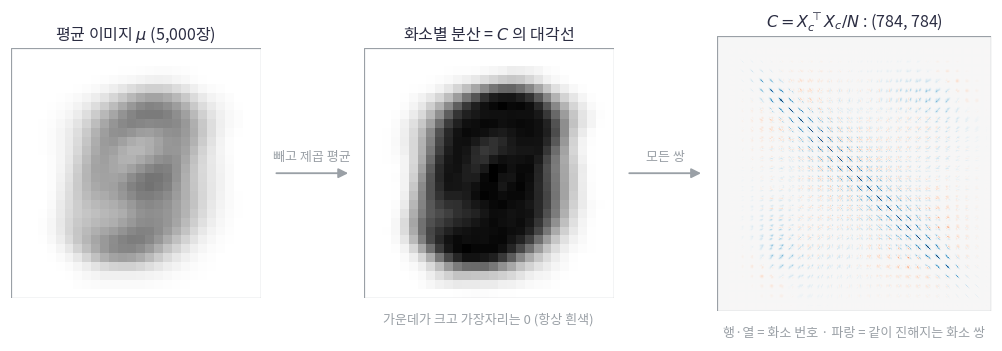

In [16]:
plot_covariance_images(mnist_mu.reshape(28, 28), mnist_var.reshape(28, 28), mnist_C, len(mnist_X))

🔍 **확인** · 가운데 화소는 이미지마다 잉크가 있다 없다 해서 분산이 크고, 가장자리는 항상 흰색이라 분산이 0입니다. $784\times784$ 공분산에서 파란 띠는 "같이 진해지는 화소 쌍"인데, 이웃 화소(번호가 1이나 28 차이)가 그렇습니다.
아래 구현은 이 계산을 함수로 쓰고, 반복문 버전과 `np.cov`로 검산합니다.

In [17]:
def covariance(X):
    """열별 평균과 분모 N의 경험 공분산: C = X_cᵀX_c/N. X: (N, D) → (mu: (D,), C: (D, D))."""
    mu = X.mean(axis=0)
    Xc = X - mu                                             # (N, D): 중심화
    return mu, Xc.T @ Xc / len(X)


def covariance_loops(X):
    """같은 공분산을 삼중 반복문으로 (검산용): C[i, j] = Σ_n (X[n, i] − μ_i)(X[n, j] − μ_j)/N."""
    mu = X.mean(axis=0)
    C = np.zeros((X.shape[1], X.shape[1]))
    for n in range(len(X)):                                 # 관측마다
        for i in range(X.shape[1]):                         # 좌표 쌍마다
            for j in range(X.shape[1]):
                C[i, j] += (X[n, i] - mu[i]) * (X[n, j] - mu[j]) / len(X)
    return C

In [18]:
# 쓰는 것: mnist_X (📎 데이터 셀) · mnist_C (2절 이미지 공분산 셀)
small = np.array([[1., 2.], [3., 0.], [5., 4.]])                       # (3, 2): 손계산 표
mu, C = covariance(small)
np.testing.assert_allclose(mu, [3., 2.])                              # 검산: 열별 평균
np.testing.assert_allclose(C, [[8/3, 4/3], [4/3, 8/3]])               # 검산: 손계산 C
np.testing.assert_allclose(C, covariance_loops(small))                # 검산: 반복문 = 행렬곱
np.testing.assert_allclose(C, np.cov(small, rowvar=False, ddof=0))    # 검산: np.cov(분모 N)과 같음
np.testing.assert_allclose(covariance(np.repeat(small, 2, axis=0))[1], C)   # 검산: 관측을 두 번 모아도 경험 분포가 같으므로 C도 같음
print('경험 공분산:\n', C)
np.testing.assert_allclose(covariance(mnist_X)[1], mnist_C)          # 검산: 위 이미지 그림의 C와 같음

경험 공분산:
 [[2.66667 1.33333]
 [1.33333 2.66667]]


🔍 **확인** · 반복문·행렬곱·`np.cov(ddof=0)`이 같은 공분산을 냅니다. 관측을 그대로 두 번 모으면 경험 분포가 같으므로 분모 $N$의 공분산도 같습니다.

## 🔑 3. 고유벡터와 SVD: 방향을 계산하기

**이 절에서 가져갈 것:** 공분산의 고유벡터 $v$는 $Cv=\lambda v$를 만족하는 방향이고 고유값 $\lambda=v^\top Cv$가 그 방향의 분산입니다. SVD $X_c=U\,\mathrm{diag}(s)V^\top$의 $V$ 열이 그 고유벡터이고 $s^2/N$이 고유값이라, 관측 행렬을 분해하면 분산이 큰 방향이 순서대로 나옵니다.

> **용어**
>
> - **고유벡터(eigenvector)·고유값(eigenvalue)**: $Cv=\lambda v$. $C$를 곱해도 방향이 안 바뀌는 $v$와 그 배율 $\lambda$. `np.linalg.eigh(C)`는 대칭 행렬용이며 고유값을 오름차순으로 돌려줍니다.
> - **특이값 분해(SVD)** $X_c=U\,\mathrm{diag}(s)V^\top$: 관측 행렬 자체의 분해. $V$의 열이 공분산의 고유벡터, $s$는 내림차순 특이값이고 $s^2/N$이 고유값. `np.linalg.svd(Xc, full_matrices=False)`.
> - **rank(계수)**: 선형 독립인 방향의 수. 0에 가까운 특이값은 없는 방향으로 셉니다.

$Cv=\lambda v$이면 $v$는 변환 $C$를 거친 뒤에도 같은 직선에 놓이는 **고유벡터**, $\lambda$는 그 방향의 배율인 **고유값**입니다.
단위 $v$에서는 $\lambda=v^TCv$가 투영 좌표의 분산입니다.
`np.linalg.eigh(C)`는 대칭 행렬의 고유값과 서로 직교하는 단위 고유벡터를 반환합니다. 고유값은 오름차순입니다.

관측 행렬 자체의 **특이값 분해(SVD)** 는 $X_c=U\operatorname{diag}(s)V^T$입니다.
`full_matrices=False`를 사용하면 $r=\min(N,D)$에 대해 $U:(N,r)$, $s:(r,)$, $V^T:(r,D)$입니다. 특이값 $s$는 내림차순입니다.
`U * s`는 $U$의 각 열에 해당 특이값을 곱합니다.

$X_c^TX_c/N=V\operatorname{diag}(s^2/N)V^T$이므로 오른쪽 특이벡터가 공분산의 방향입니다.
분해 계산은 `numpy.linalg`를 사용하고, 반환값의 정의·shape·재구성·학습 목적의 연결을 직접 검산합니다.

아래는 MNIST 공분산의 고유벡터입니다. 784차원 벡터라 28×28 이미지로 보입니다.

> **코드**
>
> - `mnist_lam[::-1]`, `mnist_V[:, ::-1]`: `eigh`의 오름차순을 뒤집어 큰 고유값부터. 고유벡터는 열이므로 열 순서를 뒤집습니다.
> - `np.cumsum(a) / a.sum()`: 앞에서부터의 누적 합을 전체로 나눈 것 = k개까지 남긴 분산의 비율.
> - `np.linalg.svd(Xc, full_matrices=False)`: 세 값 U, s, Vt를 돌려줍니다. `U * s`는 U의 열마다 특이값을 곱한 것이라 `(U * s) @ Vt`가 원래 행렬입니다.
> - `np.linalg.svd(a, compute_uv=False)`: 특이값만. `np.finfo(float).eps`는 부동소수점의 상대 정밀도, `np.count_nonzero`는 True의 개수입니다.

In [19]:
# 쓰는 것: mnist_C (2절 이미지 공분산 셀)
mnist_lam, mnist_V = np.linalg.eigh(mnist_C)                          # (784,) 오름차순 고유값, (784, 784) 열 = 고유벡터
mnist_lam, mnist_V = mnist_lam[::-1], mnist_V[:, ::-1]                # 큰 순서로
np.testing.assert_allclose(mnist_C @ mnist_V[:, 0], mnist_lam[0] * mnist_V[:, 0], atol=1e-10)   # 검산: C v = λ v
np.testing.assert_allclose(mnist_V[:, 0] @ mnist_C @ mnist_V[:, 0], mnist_lam[0])               # 검산: λ = vᵀ C v = 그 방향의 분산
mnist_cumulative = np.cumsum(mnist_lam) / mnist_lam.sum()             # (784,): 앞에서부터 남긴 분산의 비율
eigen_images = [mnist_V[:, j].reshape(28, 28) for j in range(8)]      # 고유벡터 8개를 이미지로
print("가장 큰 고유값 8개:", mnist_lam[:8].round(3), "· k=50까지 유지 분산", mnist_cumulative[49].round(3))

가장 큰 고유값 8개: [5.194 3.898 3.226 2.845 2.494 2.326 1.774 1.533] · k=50까지 유지 분산 0.829


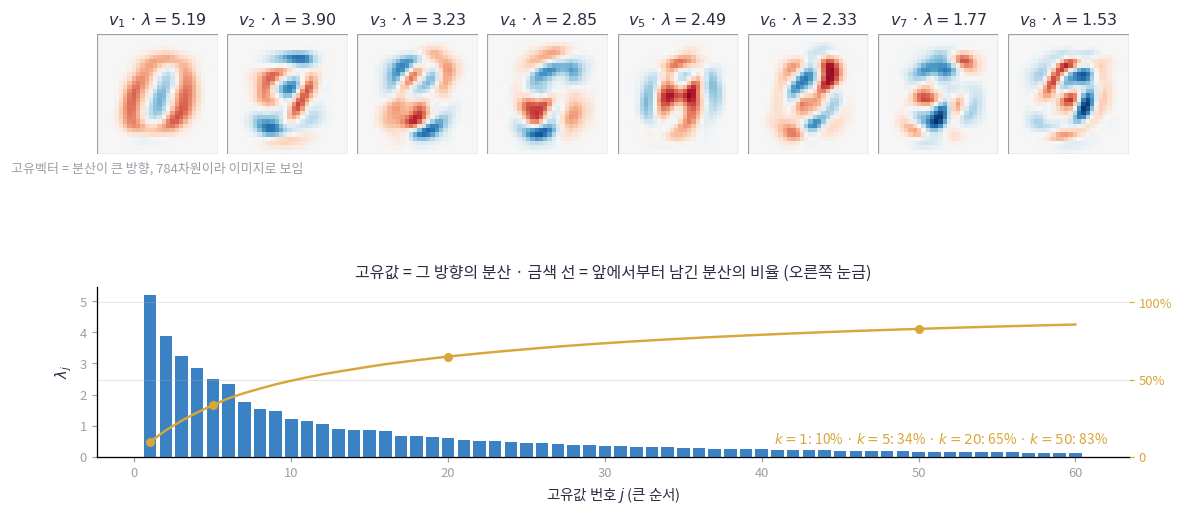

In [20]:
plot_eigen_images(eigen_images, mnist_lam[:8], mnist_lam[:60], mnist_cumulative[:60], [1, 5, 20, 50])

🔍 **확인** · 첫 고유 이미지는 "가운데 잉크가 많은가 적은가"처럼 5,000장이 가장 크게 갈리는 방향이고, 뒤로 갈수록 세밀한 무늬입니다. 고유값은 빠르게 줄어 50개면 전체 분산의 대부분을 담습니다.
아래는 2차원 점들에서 SVD와 `eigh`가 같은 방향·같은 분산을 내는지 검산합니다.

In [21]:
# 쓰는 것: covariance (2절)
rng = np.random.default_rng(110)                                      # 이 노트북의 2차원 실험용 난수 생성기. 4·6절도 이어 씁니다
angle = 0.65
rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])   # (2, 2): 회전 행렬
X_train = rng.normal(size=(240, 2)) * np.array([2.2, 0.35]) @ rotation.T + np.array([2., -1.])   # (240, 2): 긴 축 2.2, 짧은 축 0.35인 타원을 돌리고 옮김
X_valid = rng.normal(size=(160, 2)) * np.array([2.2, 0.35]) @ rotation.T + np.array([2., -1.])   # (160, 2): 같은 규칙의 검증 점
mean_train, C_train = covariance(X_train)
Xc = X_train - mean_train                                             # (240, 2)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)                     # (240, 2), (2,), (2, 2)
eigenvalues, eigenvectors = np.linalg.eigh(C_train)                   # 오름차순
np.testing.assert_allclose((U * s) @ Vt, Xc, atol=1e-13)              # 검산: 분해를 곱하면 원래 행렬
np.testing.assert_allclose(Vt @ Vt.T, np.eye(2), atol=1e-13)          # 검산: V의 열은 직교 단위
np.testing.assert_allclose(s**2 / len(X_train), eigenvalues[::-1])    # 검산: s²/N = 공분산의 고유값 (큰 순서)
np.testing.assert_allclose(C_train @ Vt.T, Vt.T * (s**2 / len(X_train)), atol=1e-13)   # 검산: C V = V diag(s²/N)
print('특이값:', s, '분산:', s**2 / len(X_train))

특이값: [34.19616  5.7151 ] 분산: [4.87241 0.13609]


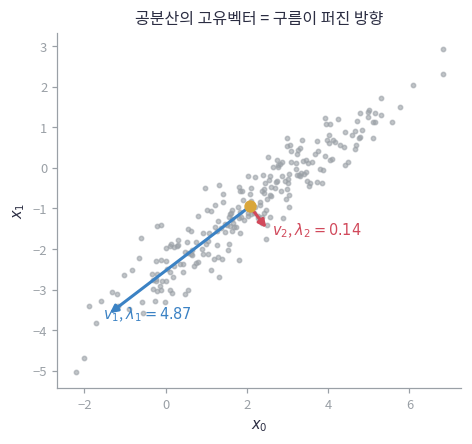

In [22]:
plot_eigen_directions(X_train, mean_train, [Vt[0], Vt[1]], s ** 2 / len(X_train))

🔍 **확인** · 두 화살표가 공분산의 고유벡터이고 길이가 $2\sqrt{\lambda}$입니다. 첫 방향이 구름의 긴 축과 나란하고, 둘째는 그에 수직인 짧은 축입니다. SVD의 $s^2/N$이 `eigh`의 고유값과 같고, $C$에 $V$를 곱하면 각 열이 고유값 배로 늘어납니다.

📎 고유벡터 $v$와 $-v$는 같은 방향의 직선을 나타냅니다. 중복 고유값이 있으면 그 부분공간 안에서 기저가 회전할 수도 있습니다.
따라서 검산에는 좌표의 부호보다 $QQ^T$와 복원 결과를 사용합니다.

**rank(계수)** 는 선형 독립인 방향의 수입니다. 중심화하면 관측들의 합이 0이므로 rank는 최대 $\min(N-1,D)$입니다.
아래의 rank-1 행렬은 두 열이 같은 정보이며, 두 번째 특이값이 수치적으로 0에 가깝습니다.
작은 특이값을 나누는 연산은 오차를 크게 만들 수 있습니다. `lstsq`의 `rcond`는 해 계산에 사용할 특이값의 상대 기준을 정합니다.

In [23]:
rank_one = np.array([[-2., -4.], [0., 0.], [2., 4.]])                # (3, 2): 둘째 열 = 첫 열 × 2 (rank 1)
rank_s = np.linalg.svd(rank_one, compute_uv=False)                    # (2,): 특이값만
tolerance = max(rank_one.shape) * np.finfo(float).eps * rank_s[0]     # 0으로 볼 기준 (가장 큰 특이값에 상대적)
assert np.count_nonzero(rank_s > tolerance) == 1, "기준보다 큰 특이값이 하나뿐이어야 rank 1입니다"
print('rank-1 특이값:', rank_s, '판정 기준:', tolerance)

rank-1 특이값: [6.32456 0.     ] 판정 기준: 4.213000162292041e-15


## 🔑 4. PCA의 목적: 복원 오차가 작은 부분공간

**이 절에서 가져갈 것:** 직교 단위 방향 $k$개로 복원할 때의 오차는 전체 분산에서 남긴 분산을 뺀 것이므로, 고유값이 큰 $k$개 방향을 남기면 오차가 가장 작습니다. 복원 오차는 **버린 고유값의 합**과 정확히 같습니다.

> **용어**
>
> - **PCA(주성분 분석)**: 공분산의 큰 고유값 $k$개에 해당하는 방향 $Q$로 $Z=X_cQ$, $\hat X=ZQ^\top+\mu$를 만드는 것. 코드에서는 SVD의 `Vt[:k].T`.
> - **Frobenius norm** $\|M\|_F^2=\sum_{ij}M_{ij}^2$: 행렬 모든 성분의 제곱합. 관측별 제곱 거리를 다 더한 것과 같습니다.
> - **유지 분산 비율**: $\sum_{j\le k}\lambda_j/\sum_j\lambda_j$. 복원 오차와 짝을 이루는 숫자입니다.

$Q^TQ=I_k$라는 조건에서 $\|X_c-X_cQQ^T\|_F^2/N$을 줄입니다.
직교하는 투영과 잔차의 제곱 길이는 더해지므로

$$\frac{\|X_c-X_cQQ^T\|_F^2}{N}
=\frac{\|X_c\|_F^2}{N}-\frac{\|X_cQ\|_F^2}{N}.$$

복원 오차는 전체 퍼짐에서 남긴 좌표의 퍼짐을 뺀 것입니다. 왼쪽을 줄이는 것은 남기는 분산을 키우는 것과 같습니다. 공분산의 고유기저에서 방향별 분산은 $\lambda_j$이므로 큰 $k$개를 선택합니다.
이 계산이 **PCA(주성분 분석)** 입니다. 남긴 분산의 비율은 $\sum_{j\le k}\lambda_j/\sum_j\lambda_j$, 남은 오차는 $\sum_{j>k}\lambda_j$입니다.
여기서 오차는 **관측별 제곱 거리의 평균**이며, 전체 원소 MSE는 이 값을 $D$로 나눕니다.

아래는 3절의 고유벡터 $k$개로 7을 복원한 것입니다. $\mu$를 빼고 $Q_k$에 투영해 좌표 $k$개를 얻고, 다시 $Q_k^\top$으로 되돌려 $\mu$를 더합니다.

> **코드**
>
> - `mnist_V[:, :k]`: 큰 고유값 k개의 고유벡터를 열로 모은 `(784, k)`. SVD에서는 `Vt[:k].T`가 같은 것입니다.
> - `np.mean(np.sum((X - X_hat) ** 2, axis=1))`: 관측마다 제곱 거리를 낸 뒤 평균. 이 노트북의 복원 오차 정의입니다.
> - `pca_transform_and_reconstruct(X_valid, *pca_fit(X_train, k=2))`: `pca_fit`이 돌려준 (mu, Q)를 별표로 펼쳐 인자 둘로 넣습니다.
> - `float(np.sum(…))`: NumPy 숫자를 파이썬 숫자로.

In [24]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · mnist_mu (2절 이미지 공분산 셀) · mnist_V, mnist_cumulative (3절 고유 이미지 셀)
pca_ks = [1, 5, 20, 50]                                               # 남길 방향 수
pca_recons, pca_distances, pca_fractions = [], [], []                 # k마다 복원 이미지, 7의 제곱 거리, 유지 분산
for k in pca_ks:
    Qk = mnist_V[:, :k]                                               # (784, k): 큰 고유값 k개의 방향
    zk = (mnist_7 - mnist_mu) @ Qk                                    # (k,): 좌표
    rec = mnist_mu + zk @ Qk.T                                        # (784,): 복원
    pca_recons.append(rec.reshape(28, 28))
    pca_distances.append(float(np.sum((mnist_7 - rec) ** 2)))         # 7 한 장의 제곱 거리
    pca_fractions.append(float(mnist_cumulative[k - 1]))
print("k:", pca_ks, "\n7의 복원 오차:", np.round(pca_distances, 2), "\n유지 분산:", np.round(pca_fractions, 3))

k: [1, 5, 20, 50] 
7의 복원 오차: [27.22 19.78 13.84  6.78] 
유지 분산: [0.099 0.335 0.65  0.829]


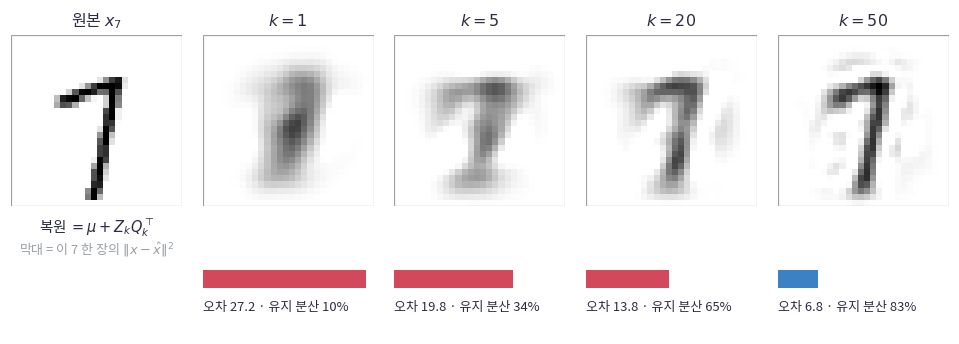

In [25]:
plot_pca_reconstruction(mnist_7.reshape(28, 28), pca_recons, pca_ks, pca_distances, pca_fractions)

🔍 **확인** · $k=1$이면 평균 이미지에 첫 방향을 조금 더한 흐릿한 덩어리이고, $k=5$에서 7의 윤곽, $k=20$에서 획이 보이고, $k=50$이면 원본에 가깝습니다. 숫자 784개를 50개로 줄여도 오차가 작습니다.
유지 분산은 5,000장 전체의 비율이고, 막대는 이 7 한 장의 오차입니다. 아래 구현은 SVD로 $Q$를 고르는 `pca_fit`과 좌표·복원 함수이며, 검산에서 복원 오차가 버린 특이값의 제곱 합과 같은지 봅니다.

In [26]:
def pca_fit(X, k):
    """PCA: 학습 평균 μ와, 중심화한 X의 SVD에서 큰 특이값 k개의 오른쪽 특이벡터 Q. X: (N, D), k: 1 ≤ k ≤ min(N, D) → (mu: (D,), Q: (D, k))."""
    if not 1 <= k <= min(X.shape):
        raise ValueError('k는 1부터 min(N,D)까지의 정수로 지정합니다.')
    mu = X.mean(axis=0)
    _, singular_values, Vt = np.linalg.svd(X - mu, full_matrices=False)   # 특이값은 내림차순
    Q = Vt[:k].T                                            # (D, k): 앞 k행을 열로
    return mu, Q


def pca_transform_and_reconstruct(X, mu, Q):
    """좌표 Z = (X − μ)Q와 복원 X̂ = ZQᵀ + μ. X: (N, D), mu: (D,), Q: (D, k) → (Z: (N, k), X̂: (N, D))."""
    # 쓰는 것: project (1절)
    Z, centered_reconstruction = project(X - mu, Q)
    return Z, centered_reconstruction + mu

In [27]:
# 쓰는 것: X_train, X_valid, s (3절 SVD 셀) · mnist_7, mnist_X (📎 데이터 셀) · pca_recons (4절 복원 셀)
mu_pca, Q_pca = pca_fit(X_train, k=1)                                 # (2,), (2, 1): 방향 하나만 남김
Z_train, reconstructed_train = pca_transform_and_reconstruct(X_train, mu_pca, Q_pca)
Z_valid, reconstructed_valid = pca_transform_and_reconstruct(X_valid, mu_pca, Q_pca)   # 검증에도 학습의 μ, Q
train_distance = np.mean(np.sum((X_train - reconstructed_train)**2, axis=1))          # 관측별 제곱 거리의 평균
valid_distance = np.mean(np.sum((X_valid - reconstructed_valid)**2, axis=1))
retained_fraction = s[0]**2 / np.sum(s**2)                            # 유지 분산 비율
np.testing.assert_allclose(train_distance, np.sum(s[1:]**2) / len(X_train), rtol=1e-12)   # 검산: 복원 오차 = 버린 특이값의 제곱 합 / N
np.testing.assert_allclose((X_train - reconstructed_train) @ Q_pca, 0, atol=1e-13)    # 검산: 잔차 ⊥ 남긴 방향
_, fully_reconstructed = pca_transform_and_reconstruct(X_valid, *pca_fit(X_train, k=2))
np.testing.assert_allclose(fully_reconstructed, X_valid, atol=1e-13)                  # 검산: k = D면 복원이 정확
print(f'1차원 압축: 유지 분산 {retained_fraction:.4%}, 학습 거리 오차 {train_distance:.6f}, 검증 거리 오차 {valid_distance:.6f}')
_, mnist_rec_fn = pca_transform_and_reconstruct(mnist_7[None], *pca_fit(mnist_X, k=50))
np.testing.assert_allclose(mnist_rec_fn[0].reshape(28, 28), pca_recons[-1], atol=1e-6)   # 검산: 위 그림의 k=50 복원과 같음 (SVD 경로)

1차원 압축: 유지 분산 97.2828%, 학습 거리 오차 0.136093, 검증 거리 오차 0.125096


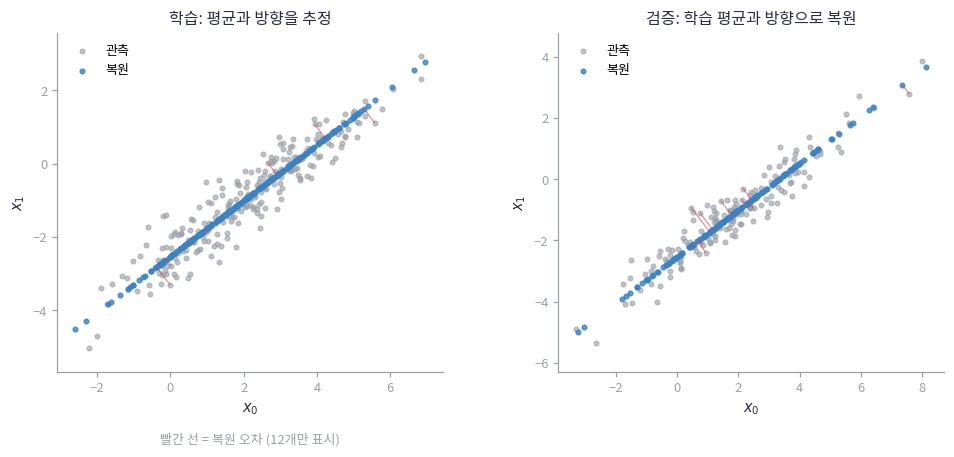

In [28]:
plot_pca_clouds([("학습: 평균과 방향을 추정", X_train, reconstructed_train), ("검증: 학습 평균과 방향으로 복원", X_valid, reconstructed_valid)])

🔍 **확인** · 점들의 긴 방향을 남기고 짧은 방향을 평균으로 복원했습니다. 학습 거리 오차가 버린 특이값의 제곱 합 $s_2^2/N$과 같고, 잔차는 남긴 방향에 직교하며, $k=2$면 복원이 정확합니다. 검증 데이터에도 학습에서 얻은 같은 $\mu,Q$를 사용합니다.
PCA는 학습 데이터의 복원 제곱 오차를 최적화합니다. 이후 분류에 유용한 방향은 라벨과 목적함수까지 고려해 확인합니다.

### 🔍 고정된 기저를 통과하는 미분

$Z=X_cQ$ 뒤에서 $G=\partial L/\partial Z$가 왔다면
$dX_c=GQ^T$, $dQ=X_c^TG$입니다. 원소별로 $dZ_{nk}=\sum_d(dX_{nd}Q_{dk}+X_{nd}dQ_{dk})$를 펼치면 두 식을 얻습니다.
이 절은 **이미 정한 $Q$를 사용하는 행렬곱**의 미분을 확인합니다. SVD로 $Q$를 선택하는 과정의 미분은 별도의 문제입니다.

In [29]:
def projection_backward(Xc, Q, G):
    """Z = X_c Q의 backward: dX_c = GQᵀ, dQ = X_cᵀG (03번의 affine backward와 같은 꼴). G: (N, k) → (dX_c: (N, D), dQ: (D, k))."""
    return G @ Q.T, Xc.T @ G

In [30]:
# 쓰는 것: rng (3절 SVD 셀)
X_check = rng.normal(size=(3, 4))                           # (N, D)
Q_check = rng.normal(size=(4, 2))                           # (D, k): 직교가 아니어도 행렬곱의 미분은 같음
G_check = rng.normal(size=(3, 2))                           # (N, k): 임의의 상류 기울기
dX, dQ = projection_backward(X_check, Q_check, G_check)


def projection_scalar():
    """검사기용: 스칼라 L = Σ (X_c Q) ⊙ G."""
    return np.sum((X_check @ Q_check) * G_check)


error_x = rel_error(dX, numerical_gradient(projection_scalar, X_check))   # X_check를 흔들어 잰 중심차분과 비교
error_q = rel_error(dQ, numerical_gradient(projection_scalar, Q_check))
assert max(error_x, error_q) < 1e-7, "두 기울기의 상대오차가 1e−7 아래여야 합니다"
print('행렬곱 backward 상대 오차:', max(error_x, error_q))

행렬곱 backward 상대 오차: 1.3094692194474316e-10


## 🔑 5. 단위를 바꾸면 남기는 방향도 바뀝니다

**이 절에서 가져갈 것:** 한 좌표의 단위를 10배 하면 그 좌표의 분산은 100배가 되어 PCA가 그 방향을 먼저 남깁니다. 표준화(열마다 분산 1)는 "어느 거리를 최적화할지"를 바꾸는 선택이지 정답이 아닙니다.

> **용어** · **표준화(standardization)**: 학습 평균을 빼고 학습 표준편차로 나누어 열마다 분산 1로 만드는 것. 코드에서는 `(X - mu) / X.std(axis=0)`.

한 열을 10배 하면 그 열의 분산은 100배입니다. PCA가 최적화하는 거리도 바뀝니다.
표준화는 학습 평균을 빼고 학습 표준편차로 나누어, 열마다 분산 1의 좌표계에서 분석하는 선택입니다.
원래 좌표의 거리와 표준화 좌표의 거리는 서로 다른 목적입니다. 어느 목적이 문제에 맞는지 먼저 정합니다.

아래는 둘째 열을 10배 한 뒤 PCA를 하고 원래 좌표로 되돌린 복원과, 표준화 뒤 PCA를 한 복원입니다.

> **코드**
>
> - `X_train * scale`: 열마다 다른 배율. `(2,)`가 각 행에 브로드캐스팅되어 둘째 열만 10배가 됩니다.
> - `X_scaled.std(axis=0)`: 열별 표준편차. `(X - mu) / std`가 표준화이고, `rec * std + mu`가 되돌리기입니다.

In [31]:
# 쓰는 것: X_train (3절 SVD 셀) · Q_pca (4절 PCA 셀) · pca_fit, pca_transform_and_reconstruct (4절)
scale = np.array([1., 10.])                                 # 둘째 열을 10배
X_scaled = X_train * scale                                  # (240, 2)
mu_scaled, Q_scaled = pca_fit(X_scaled, 1)                  # 단위를 바꾼 좌표계에서 PCA
standard_deviation = X_scaled.std(axis=0)                   # (2,): 열별 표준편차
X_standardized = (X_scaled - mu_scaled) / standard_deviation   # (240, 2): 표준화 (열마다 분산 1)
mu_standard, Q_standard = pca_fit(X_standardized, 1)        # 표준화 좌표계에서 PCA
_, scaled_reconstruction = pca_transform_and_reconstruct(X_scaled, mu_scaled, Q_scaled)
_, standardized_reconstruction = pca_transform_and_reconstruct(X_standardized, mu_standard, Q_standard)
back_to_original = (standardized_reconstruction * standard_deviation + mu_scaled) / scale   # 표준화 복원을 원래 좌표로
np.testing.assert_allclose(X_standardized.var(axis=0), 1)   # 검산: 표준화하면 열마다 분산 1
print('원래 열 단위에서 PCA 방향:', Q_pca.ravel())
print('두 번째 열을 10배 한 좌표계의 방향:', Q_scaled.ravel())

원래 열 단위에서 PCA 방향: [-0.79519 -0.60636]
두 번째 열을 10배 한 좌표계의 방향: [-0.12097 -0.99266]


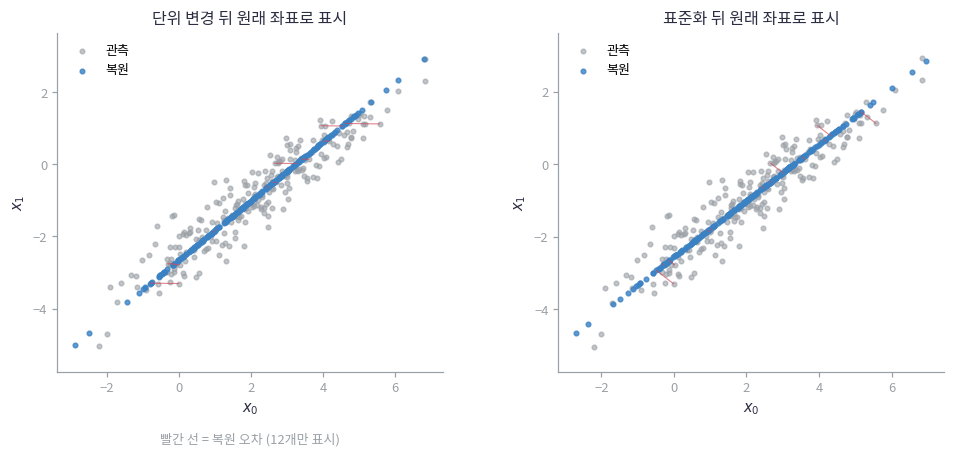

In [32]:
plot_pca_clouds([("단위 변경 뒤 원래 좌표로 표시", X_train, scaled_reconstruction / scale), ("표준화 뒤 원래 좌표로 표시", X_train, back_to_original)])

🔍 **확인** · 둘째 열을 10배 하면 PCA 방향이 둘째 축 쪽으로 기울어, 원래 좌표로 되돌리면 4절과 다른 직선 위에 복원됩니다. 표준화하면 또 다른 직선입니다. 세 결과 중 무엇이 맞는지는 "어느 좌표의 거리를 줄이려는가"에 달려 있습니다.

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 좌표와 복원 (1절)

관측 `X` $(N,D)$와 직교 단위 방향 `Q` $(D,k)$에서 좌표 `Z`와 복원 `X_hat`을 만드는 두 줄을 채우세요.

In [33]:
def exercise_project(X, Q):
    """연습 A: 좌표와 복원. X: (N, D), Q: (D, k) 직교 단위 → (Z: (N, k), X_hat: (N, D))."""
    np.testing.assert_allclose(Q.T @ Q, np.eye(Q.shape[1]), atol=1e-10)   # 검산: Q의 열이 직교 단위
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: Z = 관측을 Q 의 열에 투영한 좌표 (N, k), X_hat = 좌표를 원래 좌표계로 되돌린 복원 (N, D)
    ### 힌트: 1절 project 의 두 줄입니다. Q 의 전치를 곱하면 되돌아옵니다.
    raise NotImplementedError
    return Z, X_hat

In [34]:
def check_project(candidate):
    """1절 손계산, 7 이미지, 무작위 직교 기저의 본문 project로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: proj_x, proj_q (1절 손계산 셀) · mnist_7 (📎 데이터 셀) · img_q, img_hat (1절 7 그림 셀) · X_check, Q_check (4절 backward 셀) · project (1절)
    Z_a, H_a = candidate(proj_x[None], proj_q[:, None])
    np.testing.assert_allclose(Z_a, [[np.sqrt(2)]])                                                  # 검산: 1절 손계산 좌표
    np.testing.assert_allclose(H_a, [[1., 1.]])                                                      # 검산: 1절 손계산 복원
    Z_b, H_b = candidate(mnist_7[None], img_q[:, None])
    np.testing.assert_allclose(H_b[0], img_hat)                                                      # 검산: 7 그림의 복원
    Q_orth = np.linalg.qr(Q_check)[0]                                                                # (4, 2): QR 분해로 만든 직교 단위 열
    Z_c, H_c = candidate(X_check, Q_orth)
    Z_ref, H_ref = project(X_check, Q_orth)
    np.testing.assert_allclose(Z_c, Z_ref)                                                           # 검산: 본문 project와 같음
    np.testing.assert_allclose(H_c, H_ref)                                                           # 검산: 복원도 같음
    print("좌표와 복원: 손계산·7 이미지·project 와 일치합니다.")

run_check(check_project, exercise_project, hint="Z = X @ Q; X_hat = Z @ Q.T")

☐ exercise_project: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Z = X @ Q; X_hat = Z @ Q.T


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Z = X @ Q
X_hat = Z @ Q.T
```

</details>

### ✏️ 연습 B · 경험 공분산 (2절)

관측 `X` $(N,D)$에서 열별 평균 `mu`와 분모 $N$의 공분산 `C`를 만드는 두 줄을 채우세요.

In [35]:
def exercise_covariance(X):
    """연습 B: 경험 공분산. X: (N, D) → (mu: (D,), C: (D, D), 분모 N)."""
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: mu = 열별 평균 (D,), C = 중심화한 관측의 전치 @ 중심화한 관측 / N   (D, D)
    ### 힌트: X.mean(axis=0), (X - mu).T @ (X - mu) / len(X)
    raise NotImplementedError
    return mu, C

In [36]:
def check_covariance(candidate):
    """2절 손계산과 본문 covariance, np.cov(ddof=0)으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: cov_X (2절 손계산 셀) · X_train (3절 SVD 셀) · covariance (2절)
    mu_a, C_a = candidate(cov_X)
    np.testing.assert_allclose(mu_a, [3., 2.])                                                       # 검산: 2절 손계산 μ
    np.testing.assert_allclose(C_a, [[8 / 3, 4 / 3], [4 / 3, 8 / 3]])                               # 검산: 2절 손계산 C
    mu_b, C_b = candidate(X_train)
    mu_ref, C_ref = covariance(X_train)
    np.testing.assert_allclose(mu_b, mu_ref)                                                         # 검산: 본문 함수와 같음
    np.testing.assert_allclose(C_b, C_ref)                                                           # 검산: 공분산도 같음
    np.testing.assert_allclose(C_b, np.cov(X_train, rowvar=False, ddof=0))                           # 검산: np.cov(분모 N)
    print("공분산: 손계산·covariance·np.cov(ddof=0) 과 일치합니다.")

run_check(check_covariance, exercise_covariance, hint="mu = X.mean(axis=0); C = (X - mu).T @ (X - mu) / len(X)")

☐ exercise_covariance: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: mu = X.mean(axis=0); C = (X - mu).T @ (X - mu) / len(X)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
mu = X.mean(axis=0)
C = (X - mu).T @ (X - mu) / len(X)
```

</details>

### ✏️ 연습 C · 유지 분산과 버린 오차 (4절)

큰 순서로 정렬된 고유값 `eigenvalues` $(D,)$와 `k`에서 유지 분산 비율과 남은 오차(버린 고유값의 합)를 만드는 두 줄을 채우세요.

In [37]:
def exercise_retained(eigenvalues, k):
    """연습 C: 유지 분산 비율과 남은 오차. eigenvalues: (D,) 큰 순서, k: 남길 수 → (fraction: 숫자, remaining: 숫자)."""
    assert np.all(np.diff(eigenvalues) <= 1e-12), "고유값은 큰 순서로 정렬되어 있어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: fraction = 앞 k개의 합 / 전체 합, remaining = k번째 이후의 합
    ### 힌트: eigenvalues[:k].sum(), eigenvalues[k:].sum()
    raise NotImplementedError
    return fraction, remaining

In [38]:
def check_retained(candidate):
    """4절의 2차원 검산값과 MNIST k = 50의 실제 복원 오차로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: s, X_train (3절 SVD 셀) · retained_fraction, train_distance (4절 PCA 셀) · mnist_lam, mnist_cumulative (3절) · mnist_X (📎) · pca_fit, pca_transform_and_reconstruct (4절)
    f_a, r_a = candidate(s ** 2 / len(X_train), 1)
    np.testing.assert_allclose(f_a, retained_fraction)                                               # 검산: 4절의 유지 분산
    np.testing.assert_allclose(r_a, train_distance)                                                  # 검산: 4절의 학습 거리 오차
    f_b, r_b = candidate(mnist_lam, 50)
    np.testing.assert_allclose(f_b, mnist_cumulative[49])                                            # 검산: 3절의 누적 비율
    np.testing.assert_allclose(r_b, np.mean(np.sum((mnist_X - pca_transform_and_reconstruct(mnist_X, *pca_fit(mnist_X, 50))[1]) ** 2, axis=1)), rtol=1e-6)   # 검산: 버린 고유값의 합 = 실제 복원 오차
    print("유지 분산·남은 오차: 2차원·MNIST 복원 오차와 일치합니다.")

run_check(check_retained, exercise_retained, hint="fraction = eigenvalues[:k].sum() / eigenvalues.sum(); remaining = eigenvalues[k:].sum()")

☐ exercise_retained: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: fraction = eigenvalues[:k].sum() / eigenvalues.sum(); remaining = eigenvalues[k:].sum()


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
fraction = eigenvalues[:k].sum() / eigenvalues.sum()
remaining = eigenvalues[k:].sum()
```

</details>

### ✏️ 연습 D · 고정된 기저를 통과하는 미분 (4절)

`Z = Xc @ Q` 뒤에서 온 상류 기울기 `G` $(N,k)$로 `dXc`와 `dQ`를 만드는 두 줄을 채우세요.

In [39]:
def exercise_projection_backward(Xc, Q, G):
    """연습 D: Z = X_c Q의 backward. Xc: (N, D), Q: (D, k), G: (N, k) → (dXc: (N, D), dQ: (D, k))."""
    assert G.shape == (Xc.shape[0], Q.shape[1]), "G는 Z와 같은 모양 (N, k)이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dXc = G @ Q 의 전치 (N, D), dQ = Xc 의 전치 @ G (D, k)
    ### 힌트: 03번의 affine backward 와 같은 꼴입니다.
    raise NotImplementedError
    return dXc, dQ

In [40]:
def check_projection_backward(candidate):
    """본문 projection_backward와 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: X_check, Q_check, G_check (4절 backward 셀) · projection_backward (4절)
    dX_a, dQ_a = candidate(X_check, Q_check, G_check)
    dX_ref, dQ_ref = projection_backward(X_check, Q_check, G_check)
    np.testing.assert_allclose(dX_a, dX_ref)                                                         # 검산: 본문 함수와 같음
    np.testing.assert_allclose(dQ_a, dQ_ref)                                                         # 검산: dQ도 같음

    def scalar():
        """검사기용: 스칼라 L = Σ (X_c Q) ⊙ G."""
        return np.sum((X_check @ Q_check) * G_check)

    num_x = numerical_gradient(scalar, X_check)
    num_q = numerical_gradient(scalar, Q_check)
    assert max(rel_error(dX_a, num_x), rel_error(dQ_a, num_q)) < 1e-7, "두 기울기가 중심차분과 1e−7 안에서 같아야 합니다"
    print("행렬곱 backward: projection_backward·중심차분과 일치합니다.")

run_check(check_projection_backward, exercise_projection_backward, hint="dXc = G @ Q.T; dQ = Xc.T @ G")

☐ exercise_projection_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dXc = G @ Q.T; dQ = Xc.T @ G


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dXc = G @ Q.T
dQ = Xc.T @ G
```

</details>

### 🔍 완성 예제 · 3차원에서 남기는 차원 바꾸기

아래 검사기는 평균·직교성·선택한 부분공간·실제 복원을 확인합니다. `pca_fit`을 넣어 통과시킨 뒤, 3차원 학습 점에서 $k=1,2,3$의 검증 복원 오차가 줄어드는지 봅니다. 공분산의 `eigh`로 `pca_fit`을 다시 써서 같은 검사기에 넣어 볼 수도 있습니다.

In [41]:
def check_pca_fit(candidate):
    """pca_fit 후보를 세 크기에서 검사: 평균, Q의 직교성, 고른 부분공간(QQᵀ), 실제 복원 오차 = 버린 고유값의 합. 통과하면 문자열을 돌려줍니다."""
    # 쓰는 것: covariance (2절) · pca_transform_and_reconstruct (4절)
    local_rng = np.random.default_rng(117)
    for N, D, k in [(7, 3, 1), (9, 4, 2), (6, 3, 3)]:
        X = local_rng.normal(size=(N, D)) * np.arange(1, D + 1) + np.arange(D) * 4   # 열마다 퍼짐과 중심이 다른 관측
        mu, Q = candidate(X.copy(), k)
        assert np.shape(mu) == (D,), f"평균은 (D,) = ({D},)여야 합니다"
        assert np.shape(Q) == (D, k), f"Q는 (D, k) = ({D}, {k})여야 합니다"
        np.testing.assert_allclose(mu, X.mean(axis=0), atol=1e-12)                                   # 검산: 평균
        np.testing.assert_allclose(Q.T @ Q, np.eye(k), atol=1e-10)                                   # 검산: 직교 단위 열
        _, V = np.linalg.eigh(covariance(X)[1])
        reference_Q = V[:, -k:]                                                                      # eigh의 큰 고유값 k개 (오름차순의 뒤쪽)
        np.testing.assert_allclose(Q @ Q.T, reference_Q @ reference_Q.T, atol=1e-9)                  # 검산: 부호·회전과 무관한 부분공간 비교
        _, reconstructed = pca_transform_and_reconstruct(X, mu, Q)
        reference_loss = np.sum(np.linalg.eigvalsh(covariance(X)[1])[:D-k])                         # 버린 고유값 D−k개의 합
        np.testing.assert_allclose(np.mean(np.sum((X - reconstructed)**2, axis=1)), reference_loss, atol=1e-10)   # 검산: 복원 오차
    return '통과: 평균·직교성·선택 부분공간·실제 복원'

In [42]:
# 쓰는 것: rng (3절 SVD 셀) · pca_fit, pca_transform_and_reconstruct (4절)
print(check_pca_fit(pca_fit))
X3_train = rng.normal(size=(100, 3)) @ np.array([[2., 1., 0.], [0., .5, .3], [.1, 0., .1]]) + [1., 3., -2.]   # (100, 3): 3차원 점
X3_valid = rng.normal(size=(60, 3)) @ np.array([[2., 1., 0.], [0., .5, .3], [.1, 0., .1]]) + [1., 3., -2.]    # (60, 3)
rank_errors = []                                            # k마다 검증 복원 오차
for k in [1, 2, 3]:
    _, reconstructed = pca_transform_and_reconstruct(X3_valid, *pca_fit(X3_train, k))
    rank_errors.append(np.mean(np.sum((X3_valid - reconstructed)**2, axis=1)))
assert np.all(np.diff(rank_errors) <= 1e-12), "남기는 차원이 늘수록 오차가 줄어야 합니다"
print('3차원 검증 거리 오차 k=1,2,3:', rank_errors)

통과: 평균·직교성·선택 부분공간·실제 복원
3차원 검증 거리 오차 k=1,2,3: [np.float64(0.24538287804575815), np.float64(0.010660790846797765), np.float64(1.2443048184697054e-30)]


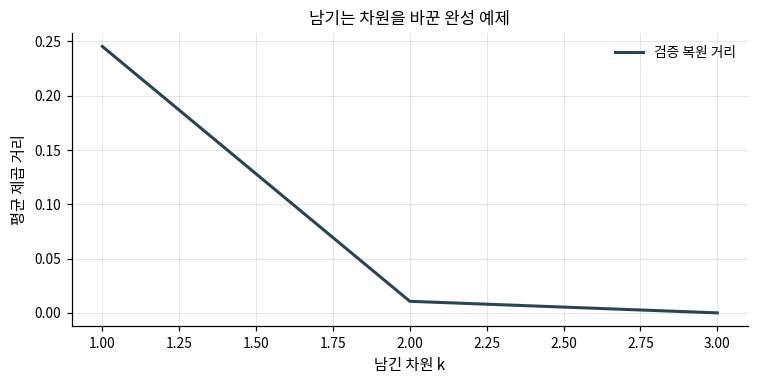

In [43]:
plot_curves([1, 2, 3], {'검증 복원 거리': rank_errors}, title='남기는 차원을 바꾼 완성 예제', xlabel='남긴 차원 k', ylabel='평균 제곱 거리')

### ✏️ 준비도 질문 · 다음으로 가기 전, 다섯 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- $Q$의 열이 직교하는 단위 벡터일 때 투영 좌표가 내적이 되는 이유를 미분으로 설명할 수 있나요? → 1절
- $X_c^TX_c$에서 합하는 축과 $N$으로 나누는 이유를 설명할 수 있나요? → 2절
- SVD의 $s^2/N$이 공분산의 고유값이 되는 식을 전개할 수 있나요? → 3절
- $Q$의 부호가 바뀌어도 같은 복원이 나오는 것을 코드로 확인할 수 있나요? → 3·4절
- 유지 분산·복원 거리·원소 MSE의 차이를 숫자로 확인할 수 있나요? → 4절

다음 [12 다변량 Gaussian·정보이론](12_gaussian_information.ipynb)에서는 공분산을 샘플 생성과 로그 밀도 계산에 사용합니다.
이후 Autoencoder에서는 $Z=X_cQ$를 학습 가능한 비선형 encoder로 확장합니다.

📎 수학 참고: [Boyd·Vandenberghe, Introduction to Applied Linear Algebra](https://web.stanford.edu/~boyd/vmls/)의 직교성·최소제곱, [Stanford CS229의 다변량 Gaussian 노트](https://cs229.stanford.edu/section/gaussians.pdf)의 공분산 정의.